## **Explainable Credit Risk Assessment System**

## **Load the Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## **Exploratory Data Analysis (EDA)**

#### **Dataset Exploration**

In [3]:
df.shape

(130324, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130324 entries, 0 to 130323
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   person_age                  130324 non-null  int64  
 1   person_income               130324 non-null  int64  
 2   person_home_ownership       130324 non-null  str    
 3   person_emp_length           126683 non-null  float64
 4   loan_intent                 130324 non-null  str    
 5   loan_grade                  130324 non-null  str    
 6   loan_amnt                   130324 non-null  int64  
 7   loan_int_rate               117776 non-null  float64
 8   loan_status                 130324 non-null  int64  
 9   loan_percent_income         130324 non-null  float64
 10  cb_person_default_on_file   130324 non-null  str    
 11  cb_person_cred_hist_length  130324 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 14.1 MB


In [5]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,130324.000000,1.303240e+05,130324,126683.000000,130324,130324,130324.000000,117776.000000,130324.000000,130324.000000,130324,130324.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,65784,NaN,25812,43108,NaN,NaN,NaN,NaN,107344,NaN
mean,27.741414,6.632856e+04,NaN,4.734621,NaN,NaN,9613.857578,11.012863,0.218164,0.172978,NaN,5.809782
std,6.427606,6.480682e+04,NaN,3.968247,NaN,NaN,6349.261140,3.214906,0.413001,0.122039,NaN,4.064022
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.851000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.559600e+04,NaN,4.000000,NaN,NaN,8075.000000,11.000000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.925000e+04,NaN,7.000000,NaN,NaN,12550.000000,13.450000,0.000000,0.230000,NaN,8.000000


In [6]:
df.isnull().sum()

person_age                        0
person_income                     0
person_home_ownership             0
person_emp_length              3641
loan_intent                       0
loan_grade                        0
loan_amnt                         0
loan_int_rate                 12548
loan_status                       0
loan_percent_income               0
cb_person_default_on_file         0
cb_person_cred_hist_length        0
dtype: int64

In [7]:
df['loan_status'].unique()

array([1, 0])

In [8]:
df.duplicated().sum()

np.int64(165)

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

#### **Univariate Analysis**

##### **Target Variable (loan_status)**

C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\1880799458.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="loan_status", palette=["#2ecc71", "#e74c3c"])


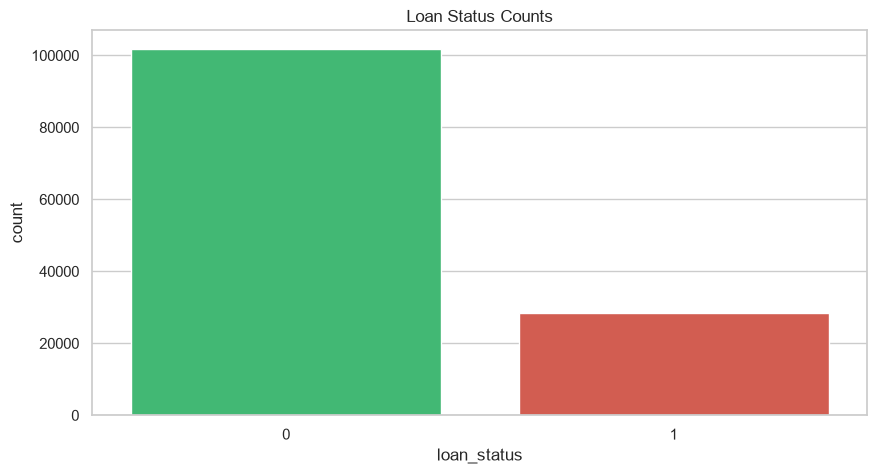

In [10]:
# 1. Target distribution: Non-Default (0) vs Default (1)
fig, ax = plt.subplots()

sns.countplot(data=df, x="loan_status", palette=["#2ecc71", "#e74c3c"])
ax.set_title("Loan Status Counts")

plt.show()

##### **Numerical Distributions**

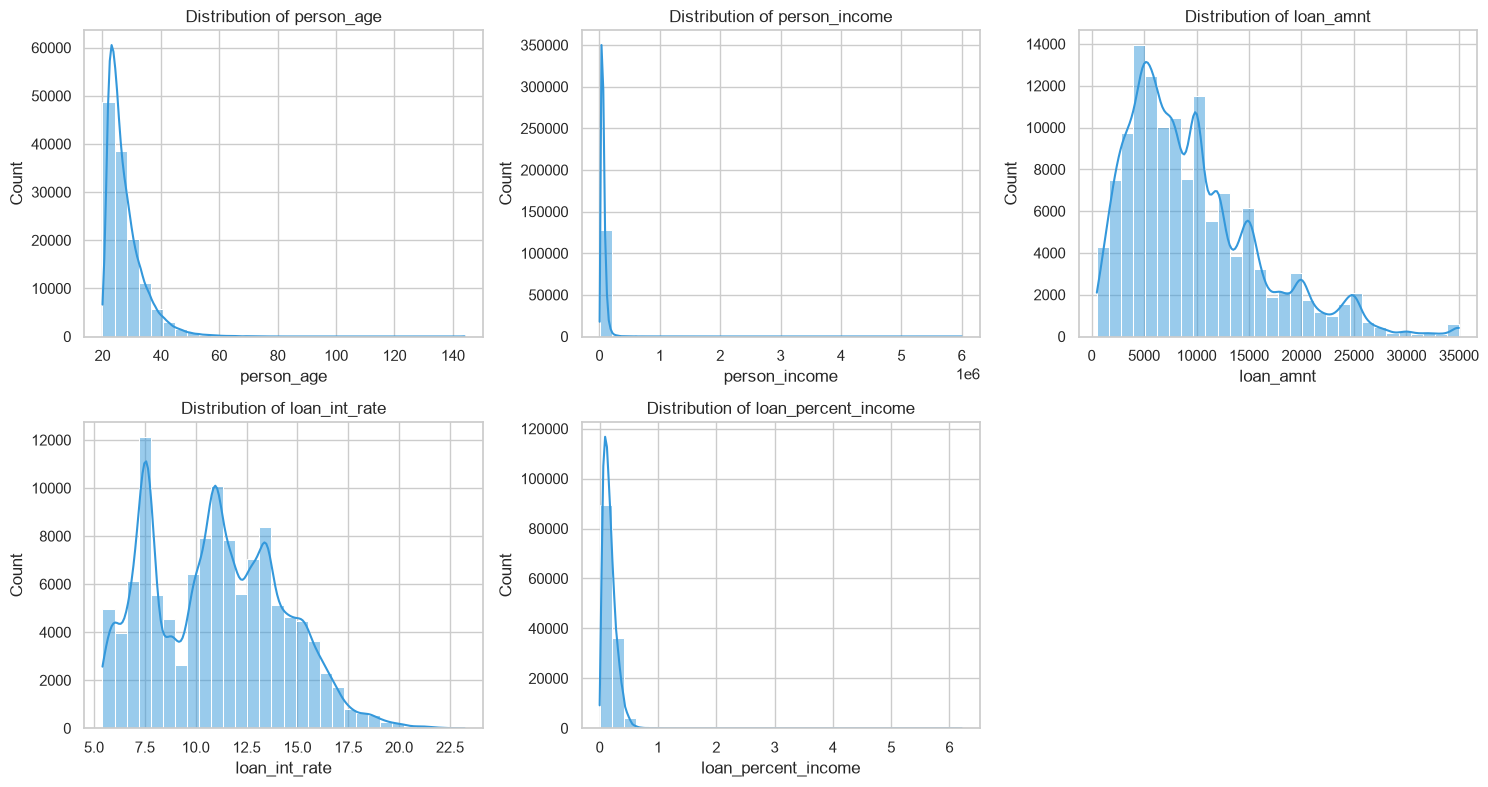

In [11]:
# Histograms with KDE for key numerical variables
num_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}")

# Hide the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


##### **Categorical Features**

C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\3391618080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
C:\Users\aduet\AppData

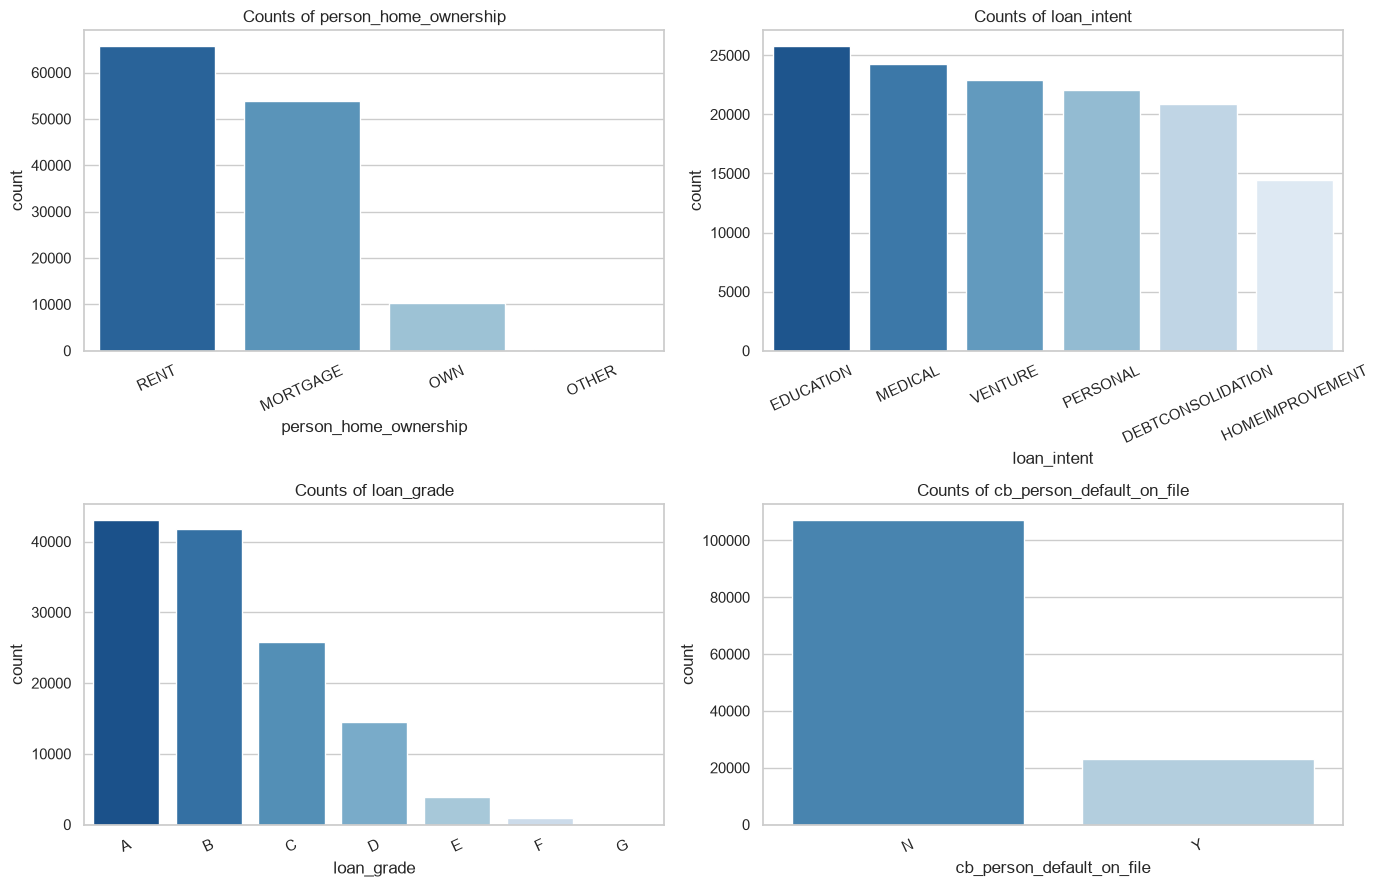

In [12]:
# Frequency countplots for categorical variables
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="Blues_r", ax=axes[i])
    axes[i].set_title(f"Counts of {col}")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


#### **Bivariate Analysis**

##### **Default rate by Categorical Factors**

C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\574247797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y="default_percent", palette

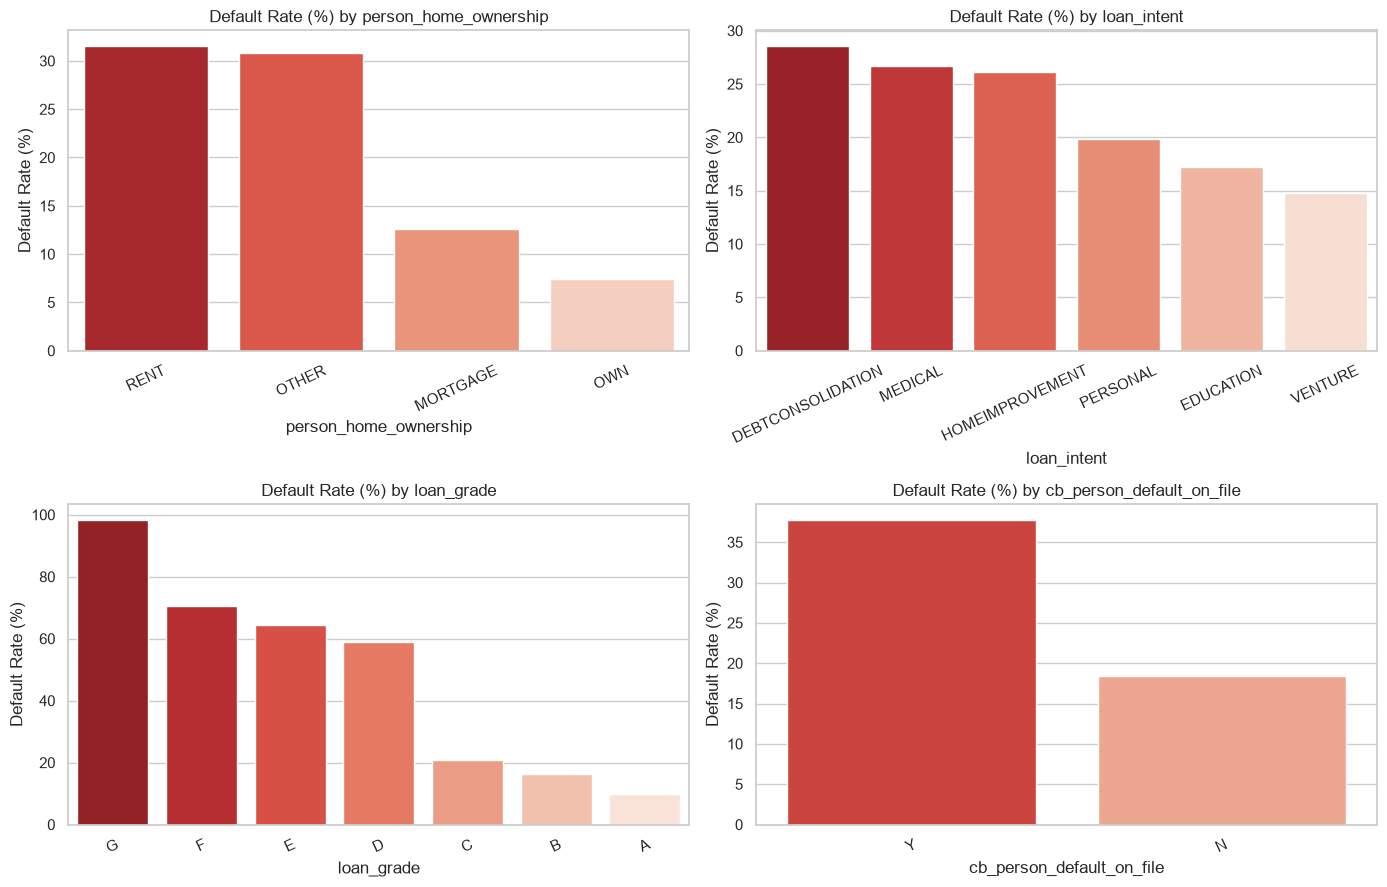

In [13]:
# Default rate (%) by Loan Grade, Loan Intent, Home Ownership, and Default History
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)["loan_status"].mean().reset_index()
    default_rate["default_percent"] = default_rate["loan_status"] * 100
    default_rate = default_rate.sort_values(by="default_percent", ascending=False)
    
    sns.barplot(data=default_rate, x=col, y="default_percent", palette="Reds_r", ax=axes[i])
    axes[i].set_title(f"Default Rate (%) by {col}")
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


##### **Key Numerics vs loan_status**

C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\4273401368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfliers=False)
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\4273401368.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Non-Default (0)", "Default (1)"])
C:\Users\aduet\AppData\Local\Temp\ipykernel_15392\4273401368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfli

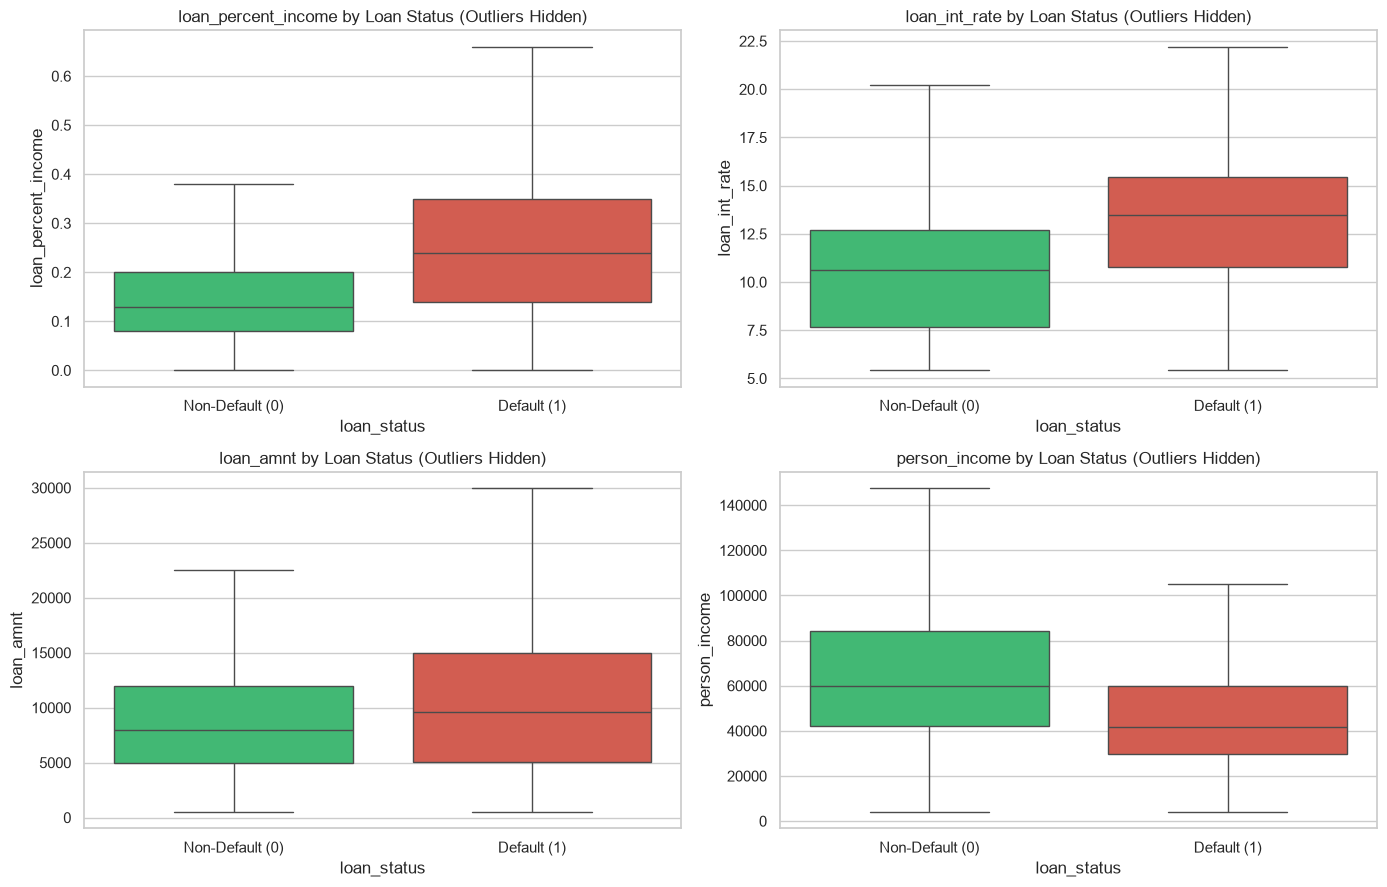

In [14]:
# Boxplots comparing key metrics between Non-Default (0) and Default (1)
features_to_compare = ["loan_percent_income", "loan_int_rate", "loan_amnt", "person_income"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(features_to_compare):
    sns.boxplot(data=df, x="loan_status", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i], showfliers=False)
    axes[i].set_xticklabels(["Non-Default (0)", "Default (1)"])
    axes[i].set_title(f"{col} by Loan Status (Outliers Hidden)")

plt.tight_layout()
plt.show()


#### **Outlier Detection**

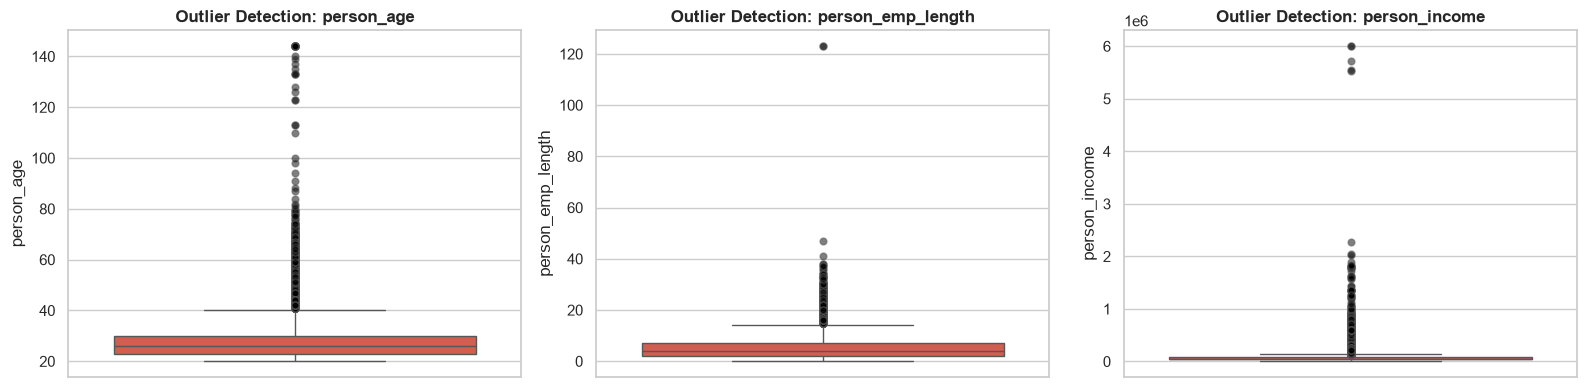

In [15]:
# Boxplots focusing on extreme values and outliers
outlier_features = ["person_age", "person_emp_length", "person_income"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        color="#e74c3c", 
        flierprops={"marker": "o", "markersize": 5, "markerfacecolor": "black", "alpha": 0.5}
    )
    axes[i].set_title(f"Outlier Detection: {col}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


Age Percentiles:
0.25     23.0
0.50     26.0
0.75     30.0
0.95     40.0
0.99     50.0
1.00    144.0
Name: person_age, dtype: float64


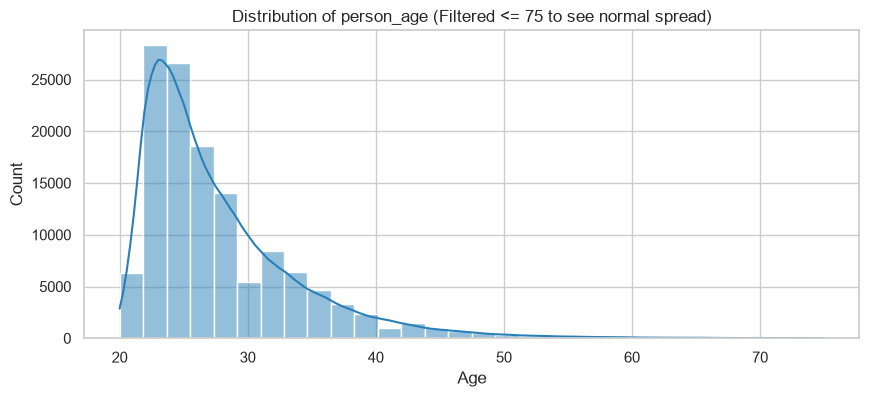

In [16]:
# 1. Summary statistics for age
print("Age Percentiles:")
print(df["person_age"].quantile([0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

# 3. Age distribution zoomed in: Normal range (<= 75) vs Extreme (> 75)
plt.figure(figsize=(10, 4))
sns.histplot(df[df["person_age"] <= 75]["person_age"], bins=30, kde=True, color="#2980b9")
plt.title("Distribution of person_age (Filtered <= 75 to see normal spread)", fontsize=12)
plt.xlabel("Age")
plt.show()


In [17]:
(df['person_age'] > 100).sum()

np.int64(26)

In [18]:
# In real life:
# - A person cannot have employment length greater than their age
# - A person cannot have credit history longer than their age

emp_gt_age = df[df["person_emp_length"] > df["person_age"]]
cred_gt_age = df[df["cb_person_cred_hist_length"] > df["person_age"]]
emp_gt_60 = df[df["person_emp_length"] > 60]

print(f"Records where employment length > age : {len(emp_gt_age)}")
print(f"Records where credit history > age    : {len(cred_gt_age)}")
print(f"Records where employment length > 60  : {len(emp_gt_60)}")

# Display the impossible employment records
if len(emp_gt_age) > 0:
    print("\nSample records where employment length > age:")
    display(emp_gt_age[["person_age", "person_emp_length", "person_income", "loan_amnt"]])


Records where employment length > age : 2
Records where credit history > age    : 0
Records where employment length > 60  : 2

Sample records where employment length > age:


,person_age,person_emp_length,person_income,loan_amnt
0,22,123.0,59000,35000
210,21,123.0,192000,20000


##### **Statistical IQR Outlier Summary for All Numerical Columns**

In [19]:
# Standard 1.5 * IQR outlier detection table
outlier_summary = []

for col in df.select_dtypes(include=["number"]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = (num_outliers / len(df)) * 100
    
    outlier_summary.append({
        "Feature": col,
        "Min": df[col].min(),
        "Max": df[col].max(),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": num_outliers,
        "Outlier %": f"{pct_outliers:.2f}%"
    })

pd.DataFrame(outlier_summary)

,Feature,Min,Max,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,person_age,20.00,144.00,12.50,40.50,6030,4.63%
1,person_income,4000.00,6000000.00,-22600.00,140360.00,6137,4.71%
2,person_emp_length,0.00,123.00,-5.50,14.50,3173,2.43%
3,loan_amnt,500.00,35000.00,-6325.00,23875.00,5804,4.45%
4,loan_int_rate,5.42,23.22,-0.42,21.78,25,0.02%
5,loan_status,0.00,1.00,0.00,0.00,28432,21.82%
6,loan_percent_income,0.00,6.21,-0.12,0.44,3227,2.48%
7,cb_person_cred_hist_length,2.00,34.00,-4.50,15.50,4447,3.41%


#### **Correlation Heatmap**

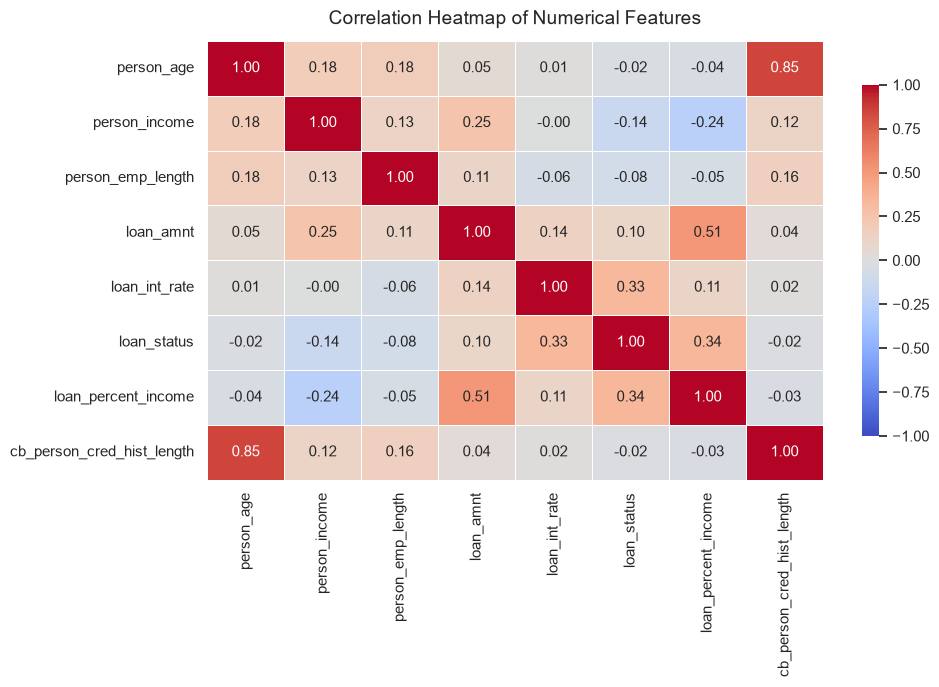

In [20]:
# Correlation matrix of numerical variables
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


## **Data Validation and Outlier Handling**

- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove rows with zero or negative income and loan amount.

In [21]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows 
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or above 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]
print(f"Rows after removing ages below 18 and above 100 : {df_copy.shape[0]}")

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]
print(f"Rows after removing employment length greater than age : {df_copy.shape[0]}")

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]
print(f"Rows after removing 0 or negative income/loan amount : {df_copy.shape[0]}")

#check if the interest rate looks realistic.
print("Loan interest rate range from (min: 5.42 and max: 23.22)")

Original Rows: 130324


Rows after removing duplicates : 130159
Rows after removing ages below 18 and above 100 : 130133
Rows after removing employment length greater than age : 126498
Rows after removing 0 or negative income/loan amount : 126498
Loan interest rate range from (min: 5.42 and max: 23.22)


## **Features, Target and Train/Test Split**

In [22]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [24]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## **Handle Class Imbalance**

In [25]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weights = neg/pos

In [26]:
scale_weights

np.float64(3.59364502950522)

## **Data Preprocessing - Pipelines & Column Transformer**

#### **Preprocessing for Logistic Regression**

- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [27]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot Encoding

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [28]:
preprocessor_lr

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

#### **Preprocessing for XGBoost**

- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [29]:
#XGBoost: Impute numeric only (No Scaling), impute + One-Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [30]:
preprocessor_xg

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## **Evaluation Helper Function**

- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold = None):

  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrics
  accuracy     = accuracy_score(y_test, y_pred)    # Overall model's preformance
  precision    = precision_score(y_test, y_pred)   # When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      # of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          # Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")

  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot = True, fmt = "d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()
     

## **Stratified Cross-Validation**

- One single train-test split may not be reliable.
- We split the training data into five folds instead.
- Each fold keeps the same default vs repaid ratio.
- We check the model's score across all folds.

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [33]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter = 1000, 
        class_weight = "balanced", 
        random_state = 42))
])

In [34]:
# XGboost Model

from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator = 300, 
        max_depth = 5, 
        learning_rate = 0.1,
        scale_pos_weight = scale_weights,
        random_state = 42
    ))
])

In [35]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline), ("XGBoost", xgb_cv_pipeline)]:
    cv_results = cross_validate(pipe, X_train , y_train, cv = cv, scoring = scoring, n_jobs = -1)

    print(cv_name)
    print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
    print(f"Precision : {cv_results['test_precision'].mean()}")
    print(f"Recall : {cv_results['test_recall'].mean()}")
    print(f"F1 : {cv_results['test_f1'].mean()}")
    print()

Logistic Regression
ROC-AUC : 0.8664449493064378
Accuracy : 0.810006167406215
Precision : 0.545023951712213
Recall : 0.7706763504312301
F1 : 0.6384810077455596

XGBoost
ROC-AUC : 0.928859342887202
Accuracy : 0.8908575497117743
Precision : 0.7364390783649333
Recall : 0.776713572401271
F1 : 0.7560102095553642



## **Baseline Model - Logistic Regression**

In [36]:
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight = "balanced"))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

Baseline Logistic Model Metrics:
Accuracy : 0.81
Precision : 0.55
Recall : 0.77
F1 : 0.64

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87     19793
           1       0.55      0.77      0.64      5507

    accuracy                           0.81     25300
   macro avg       0.74      0.80      0.76     25300
weighted avg       0.85      0.81      0.82     25300



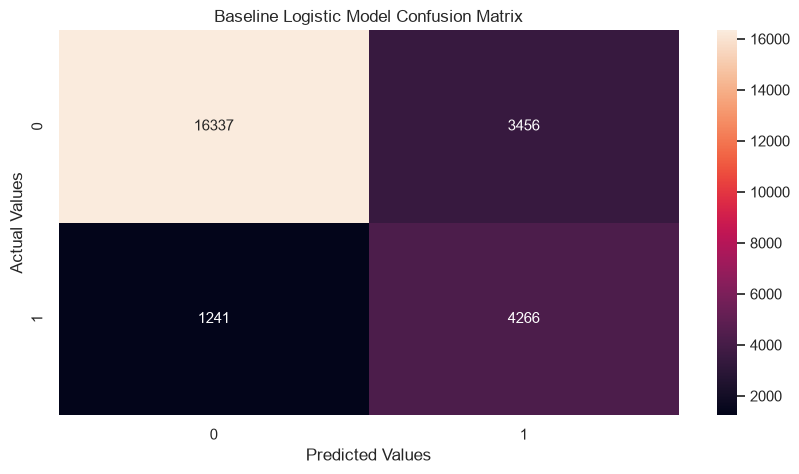

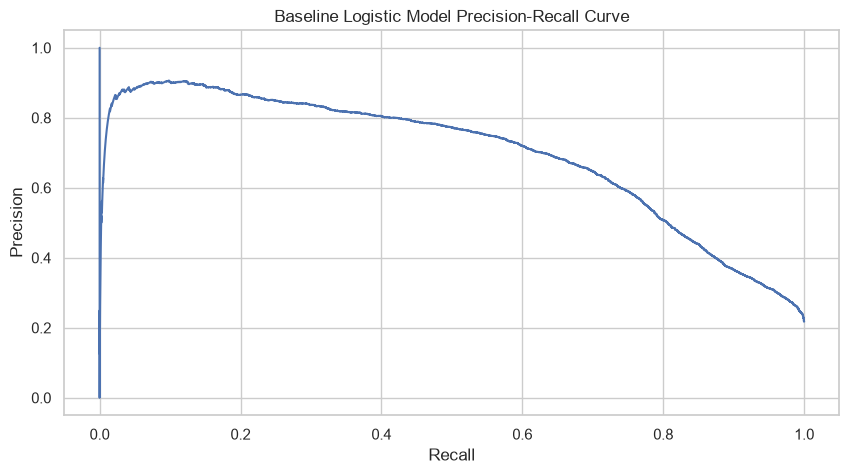

In [37]:
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

## **XGBoost**

In [38]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        learning_rate = 0.1,
        scale_pos_weight = scale_weights,
        random_state = 42
    ))
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

XGBoost Model Metrics:
Accuracy : 0.90
Precision : 0.78
Recall : 0.78
F1 : 0.78

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     19793
           1       0.78      0.78      0.78      5507

    accuracy                           0.90     25300
   macro avg       0.86      0.86      0.86     25300
weighted avg       0.90      0.90      0.90     25300



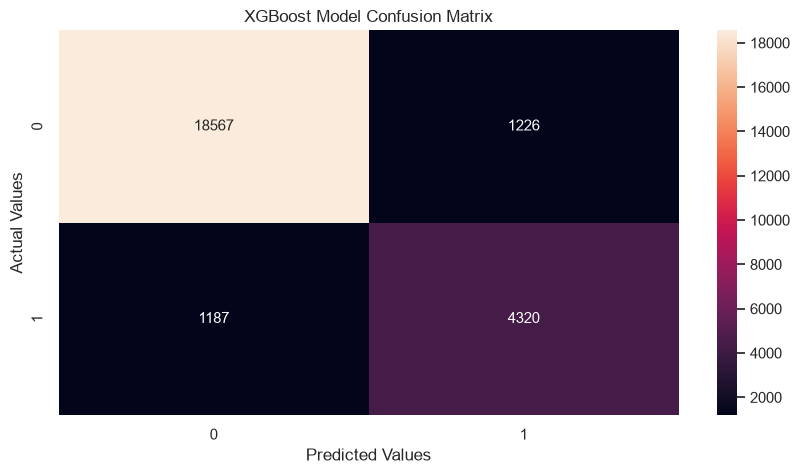

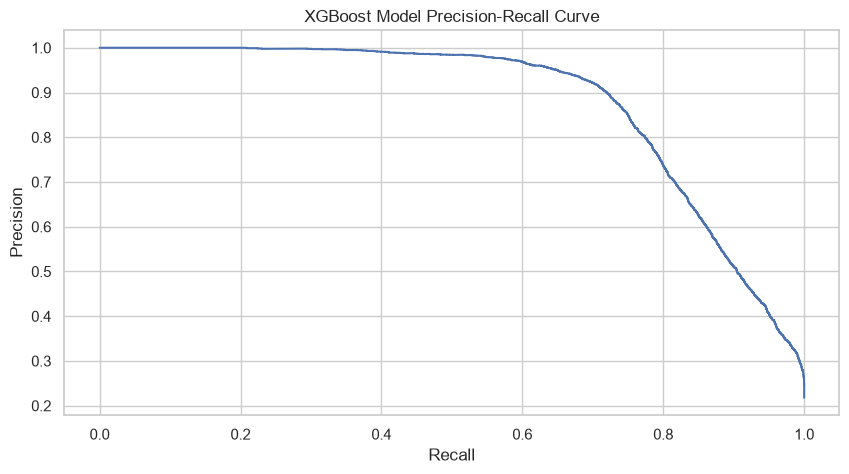

In [39]:
evaluate_model("XGBoost Model", xgb_model, X_test, y_test)

## **XGBoost Hyperparameter Tuning**

In [40]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        learning_rate = 0.1,
        scale_pos_weight = scale_weights,
        random_state = 42))
])

xg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators"     : randint(150, 600),
    "classifier__max_depth"        : randint(3, 9),
    "classifier__learning_rate"    : uniform(0.01, 0.5),
    "classifier__subsample"        : uniform(0.6, 0.4),                  # Row sampling
    "classifier__colsample_bytree" : uniform(0.6, 0.4),                  # column sampling
    "classifier__min_child_weight" : randint(1, 10),
    "classifier__gamma"            : uniform(0 , 5)
}

# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [42]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter = 150,
    cv = cv,
    scoring = "average_precision",
    n_jobs = -1,
    verbose = 1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...te=42, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....0023EA1778A50>, 'classifier__gamma': <scipy.stats....0023EA1779710>, 'classifier__learning_rate': <scipy.stats....0023EA16EC510>, 'classifier__max_depth': <scipy.stats....0023EA29757D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index

In [43]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.94


In [44]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.7463717375938501),
 'classifier__gamma': np.float64(1.0596846944261884),
 'classifier__learning_rate': np.float64(0.3020140122109026),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 1,
 'classifier__n_estimators': 337,
 'classifier__subsample': np.float64(0.6121751452865837)}

## **Compare the Models side-by-side**

Logistic Regression Metrics:
Accuracy : 0.81
Precision : 0.55
Recall : 0.77
F1 : 0.64

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87     19793
           1       0.55      0.77      0.64      5507

    accuracy                           0.81     25300
   macro avg       0.74      0.80      0.76     25300
weighted avg       0.85      0.81      0.82     25300



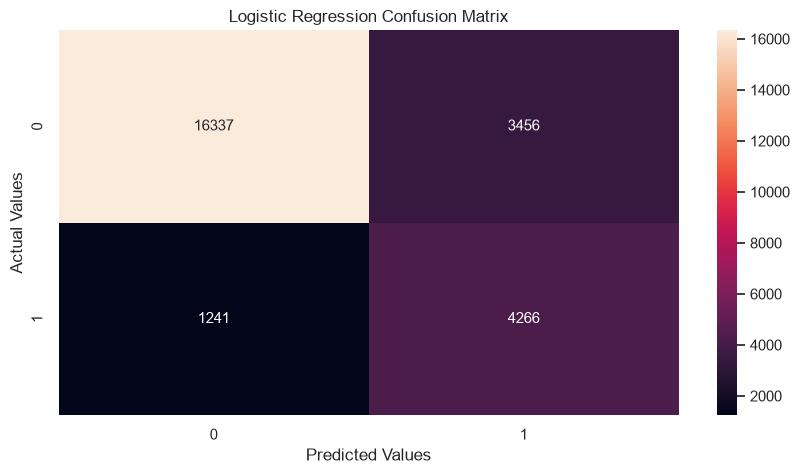

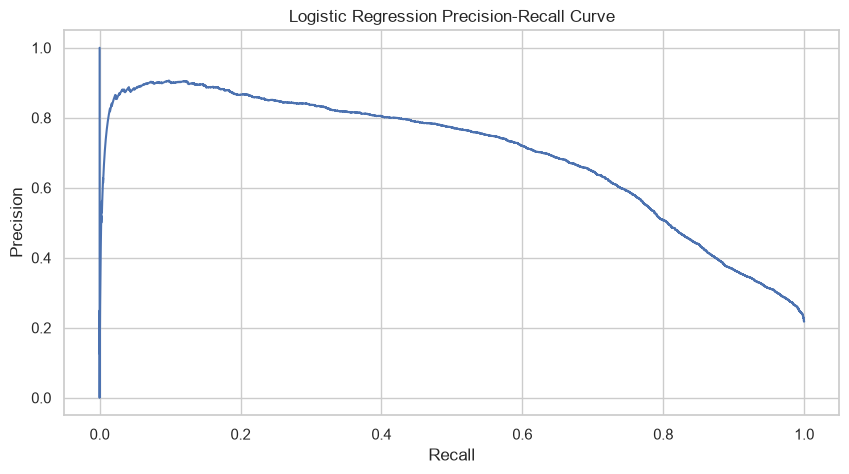

In [45]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.95
Precision : 0.89
Recall : 0.87
F1 : 0.88

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     19793
           1       0.89      0.87      0.88      5507

    accuracy                           0.95     25300
   macro avg       0.93      0.92      0.92     25300
weighted avg       0.95      0.95      0.95     25300



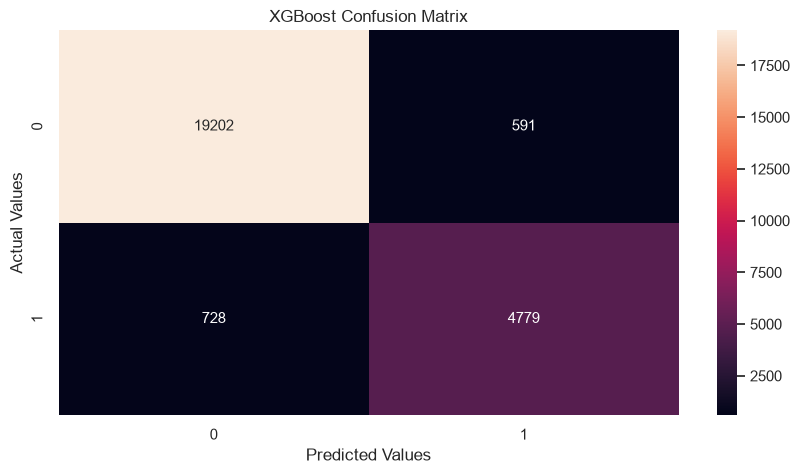

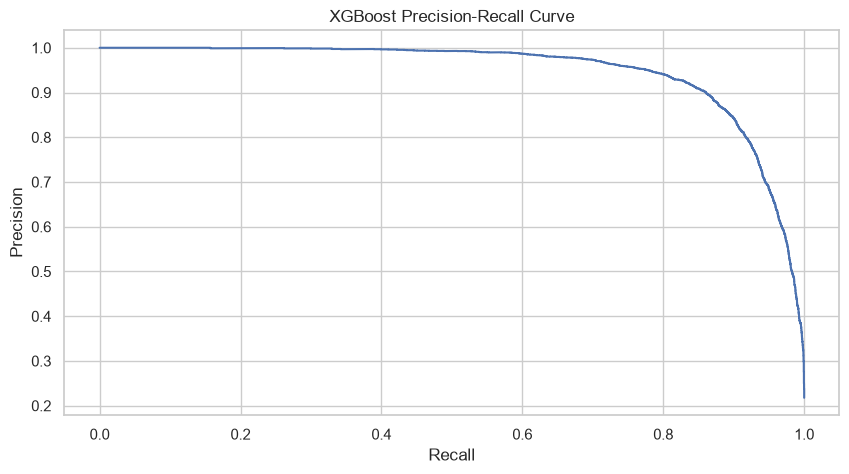

In [46]:
evaluate_model("XGBoost", random_search, X_test, y_test)

## **Optimizing the Classification Threshold**

- The model gives a probability, not a direct yes or no.
- We decide a cut-off point to turn it into a decision.
- We check different cut-off points and pick the best one.

f:\Projects 2026\Machine Learning\Credit Risk Assessment System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Projects 2026\Machine Learning\Credit Risk Assessment System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Projects 2026\Machine Learning\Credit Risk Assessment System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

XGBoost Metrics:
Used Threshold : 1.00
Accuracy : 0.78
Precision : 0.00
Recall : 0.00
F1 : 0.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     19793
           1       0.00      0.00      0.00      5507

    accuracy                           0.78     25300
   macro avg       0.39      0.50      0.44     25300
weighted avg       0.61      0.78      0.69     25300



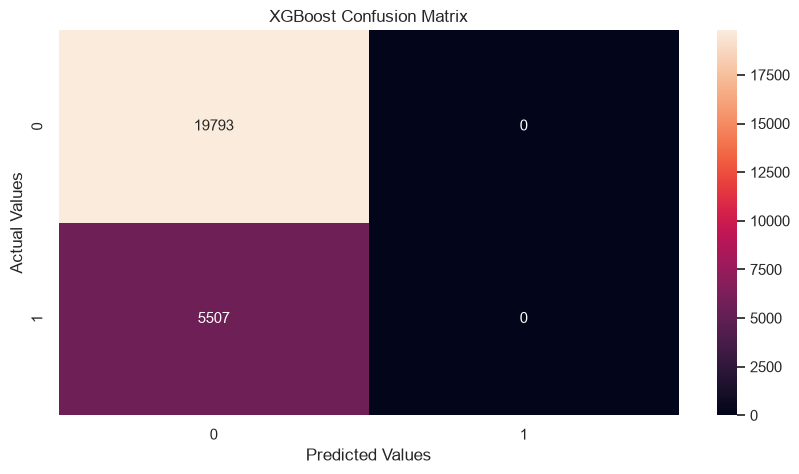

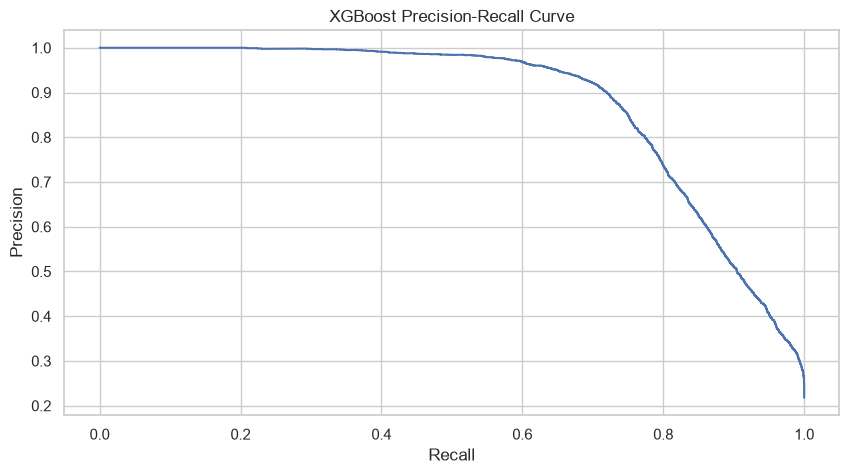

In [ ]:
# Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2 * (precisions-recalls) / (precisions + recalls + 1e-9)

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

## **>> Probability Calibration**

- Sometimes a model's probability doesn't mean what it says. For example, 30% risk should truly mean a 30% chance.
- We check this with a calibration plot. We fix it if the probabilities are off.

----------------------------------------------------------------------------------

Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid   ->   Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression      ->   Learn a flexible mapping from old prob. - better prob. (non-linear calibration)
3. Temperature Scaling      ->   Adjust the confidence of neural-network predictions using one temperature    

In [48]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

calibrated_model = CalibratedClassifierCV(
    best_model,
    method = "sigmoid",
    cv = 5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...te=42, ...))])"
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0023EA296A7D0>, <

In [49]:
# 2. Get probabilites

uncalibrated  = xg_model.predict_proba(X_test)[:,1]
calibrated    = calibrated_model.predict_proba(X_test)[:,1]

In [50]:
# 3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins = 10)

In [51]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins = 10)

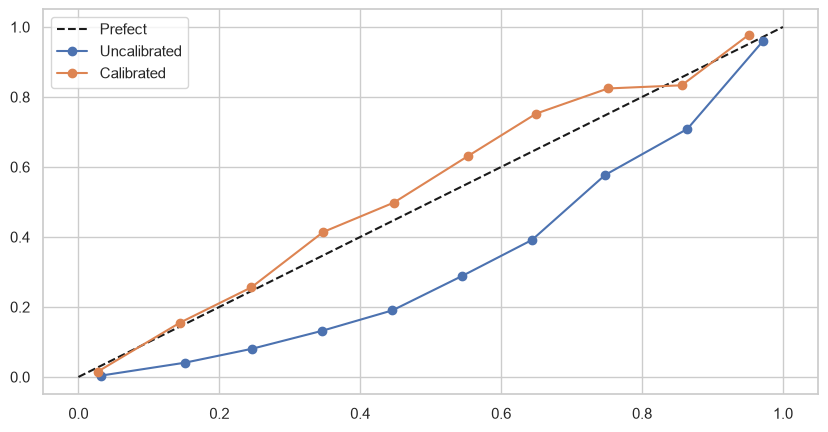

In [52]:
# 4. plot
plt.plot([0,1], [0,1], 'k--', label = "Prefect")

plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)

plt.legend()

## **>> SHAP Interpretation - Global & Local**

In [53]:
import shap

f:\Projects 2026\Machine Learning\Credit Risk Assessment System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
# 2. Get the Trained XGBoost classifier model out of the pipeline
xgb_classifier = xg_model.named_steps['classifier']

In [55]:
# 3. Transform X_test using the same preprocessing used for training
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [56]:
# 4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [57]:
# 5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns = feature_names)

In [58]:
# 6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [59]:
# 7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-0.09622565,  0.49587068,  0.06598408, ..., -0.00757874,
        -0.00994819,  0.        ],
       [ 0.14649369, -1.011639  , -0.00445582, ..., -0.01130635,
        -0.03104801,  0.        ],
       [ 0.05004255, -0.859383  , -0.05436223, ..., -0.01223855,
        -0.03755803,  0.        ],
       ...,
       [ 0.1563192 ,  0.00774854,  0.02385122, ..., -0.00837166,
        -0.01193846,  0.        ],
       [ 0.11148619, -0.6713687 , -0.12855278, ..., -0.01097424,
        -0.04261239,  0.        ],
       [-0.11259422,  0.2825704 , -0.18152805, ..., -0.00985342,
         0.09398254,  0.        ]], shape=(25300, 26), dtype=float32)

#### **Global Explanation**
- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

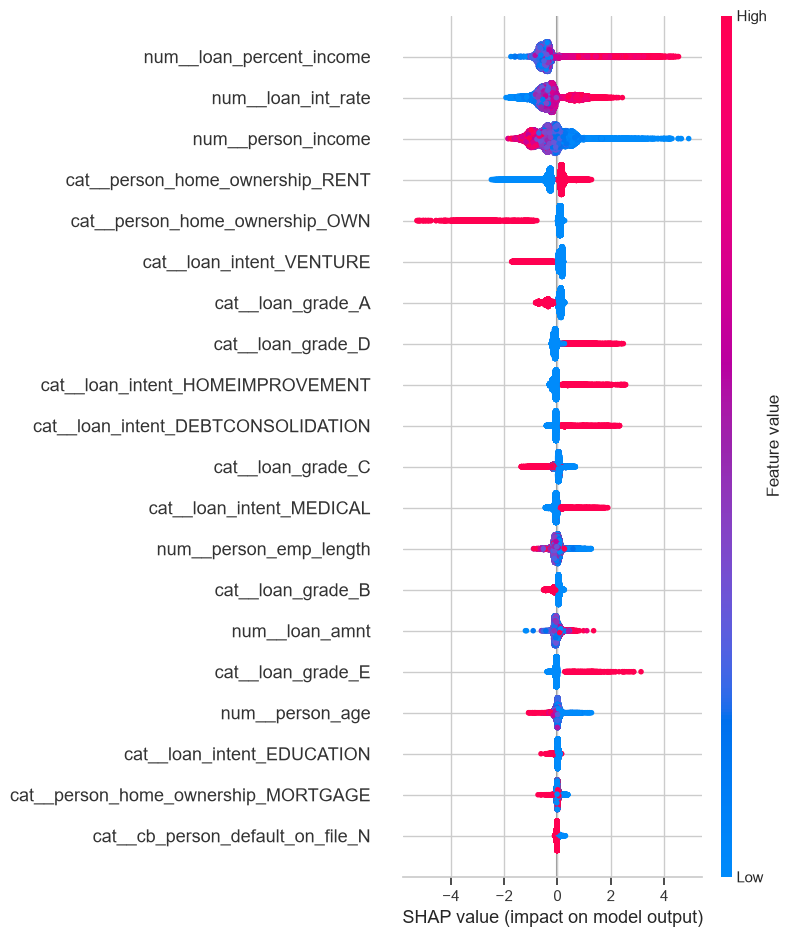

In [60]:
shap.summary_plot(shap_values, X_test_df)

#### **Local explanation**
- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

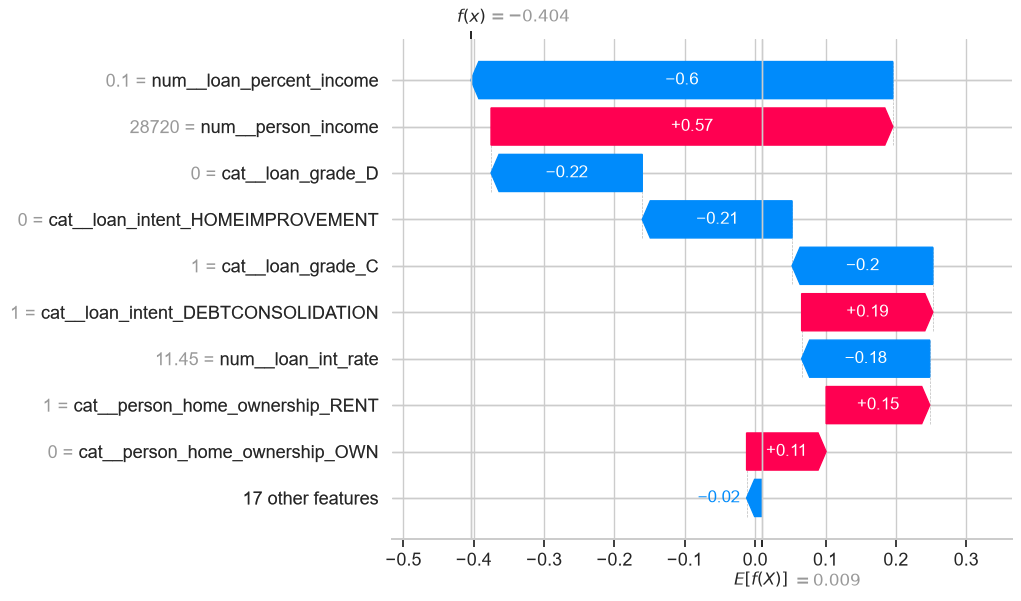

In [61]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## **Analyzing False Positives & False Negatives**

- The model will not be perfect.
- False positives are safe people wrongly marked risky.
- False negatives are risky people wrongly marked safe.
- We study these cases to understand where the model struggles.

In [62]:
# Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [63]:
# Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [64]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [65]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 591
False Negative : 728


## **Save the Final Model**

In [66]:
import joblib

In [67]:
joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [68]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']